# Iris Flower Classification using K-Nearest Neighbors (KNN)

## Objective
The goal of this project is to classify Iris flowers into three species:
- Setosa
- Versicolor
- Virginica

using the K-Nearest Neighbors (KNN) classification algorithm.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [6]:
df = pd.read_csv('iris.csv')

In [11]:
df.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [15]:
df.shape

(150, 5)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [17]:
df.describe()


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [18]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

# Performing EDA

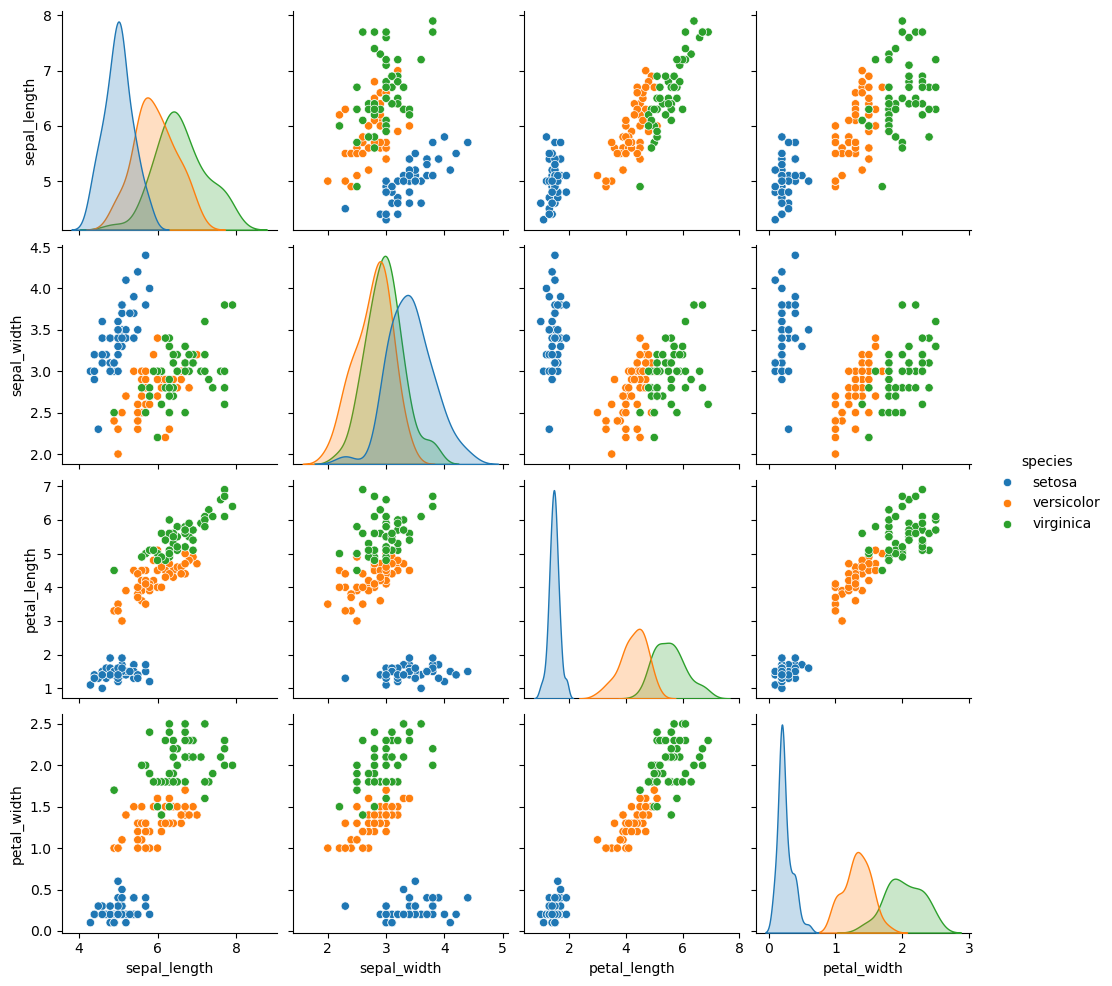

In [21]:
sns.pairplot(
    df,
    hue='species'
)
plt.show()

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['species'] = le.fit_transform(df['species'])

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


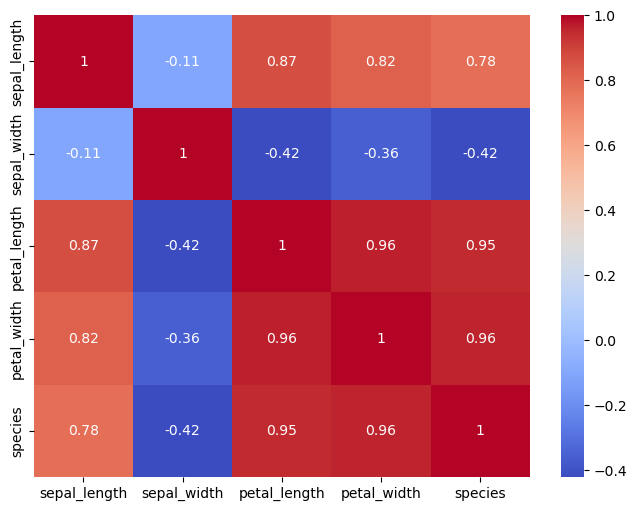

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

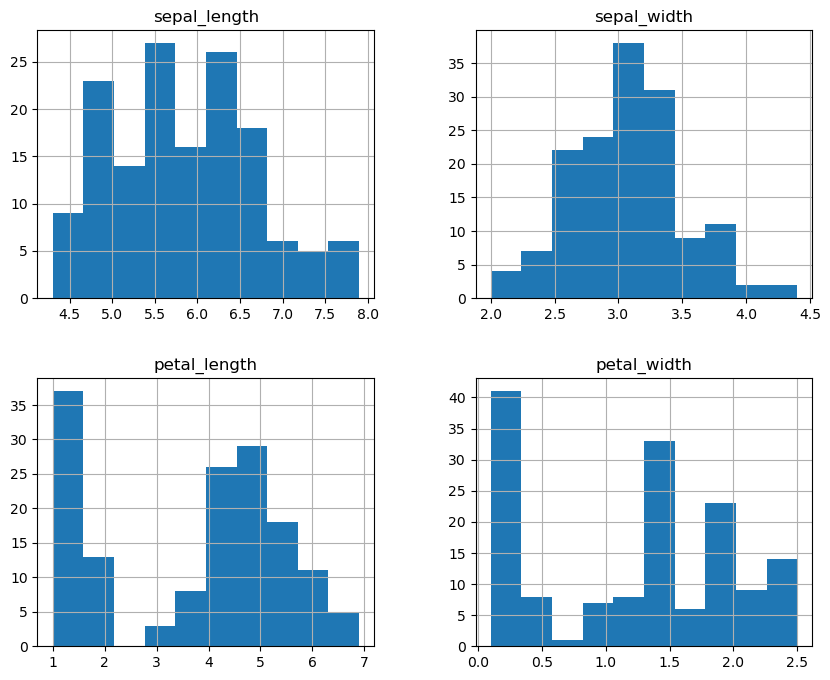

In [23]:
df.hist(
    figsize=(10,8)
)

plt.show()

In [26]:
X = df.drop("species", axis=1)

y = df["species"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


# FEATURE SCALING 

In [29]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

KNN calculates distances between points.
Therefore all features must be on the same scale.

# Building the knn model

In [30]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train,y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [32]:
y_pred = knn.predict(X_test)

# Evaluating Model metrics

In [34]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


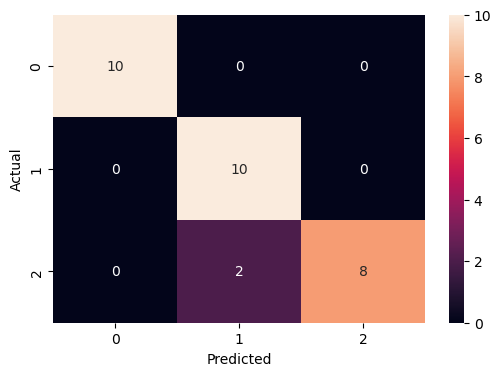

In [35]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True,fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# CLASSIFICATION REPORT

In [36]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



# Finding Best K Value

In [38]:
scores = []

for k in range(1,21):

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    scores.append(
        accuracy_score(
            y_test,
            pred
        )
    )

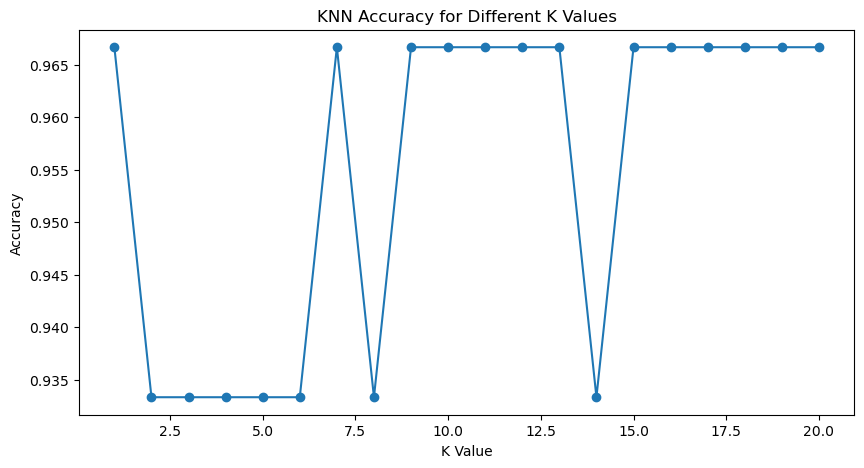

In [40]:
plt.figure(figsize=(10,5))

plt.plot(range(1,21),scores,marker='o')

plt.xlabel("K Value")
plt.ylabel("Accuracy")

plt.title("KNN Accuracy for Different K Values")

plt.show()

In [41]:
best_k = np.argmax(scores) + 1

print("Best K:",best_k)

Best K: 1


# Training final model

In [42]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)

final_knn.fit(
    X_train,
    y_train
)

final_pred = final_knn.predict(X_test)

In [43]:
# final Accuracy score
print(
    "Final Accuracy:",
    accuracy_score(
        y_test,
        final_pred
    )
)

Final Accuracy: 0.9666666666666667


## Conclusion

The K-Nearest Neighbors algorithm was successfully applied to classify Iris flowers.

Key observations:

- Dataset contained 150 flower samples.
- Data was standardized before training.
- Multiple K values were tested.
- Best performance was achieved at K = 1.
- Final accuracy achieved was 96.67%.

The model successfully classified Iris flower species with high accuracy.